# Quebras estruturais e eventos

**Objetivo:** verificar se a serie muda de regime ao longo do tempo, comparar periodos relevantes e detectar possiveis pontos de ruptura.

Em series de saude isso e especialmente importante porque nem sempre faz sentido assumir que o processo gerador dos dados foi estavel do inicio ao fim. Mudancas de comportamento podem refletir:
- ondas epidemiologicas;
- alteracoes de notificacao ou acesso ao sistema;
- mudancas abruptas de nivel medio e de variabilidade.

Nesta etapa vamos combinar:
- comparacao entre **blocos temporais do proprio periodo estudado**;
- deteccao de **ondas** com base na media movel de 30 dias;
- inspeccao de mudancas abruptas de **nivel** e **variancia**;
- deteccao automatica de **changepoints** em escala mensal.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import rankdata

In [9]:
def classificar_bloco_temporal(data):
    if data < pd.Timestamp("2014-01-01"):
        return "2012-2013"
    if data < pd.Timestamp("2016-01-01"):
        return "2014-2015"
    return "2016-2018"


def pettitt_test(serie):
    """Teste de Pettitt para detectar uma quebra principal em uma serie ordenada."""
    serie = serie.dropna()
    x = serie.to_numpy(dtype=float)
    n = len(x)
    ranks = rankdata(x)
    u_t = 2 * np.cumsum(ranks) - np.arange(1, n + 1) * (n + 1)
    k = np.abs(u_t).max()
    t = int(np.abs(u_t).argmax())
    p = float(min(1.0, 2 * np.exp((-6 * (k**2)) / (n**3 + n**2))))
    return {
        "data_changepoint": serie.index[t],
        "estatistica_k": float(k),
        "p_valor_aprox": p,
        "n_observacoes": int(n),
    }


def detectar_candidatos_por_score(serie_score, distance=45, quantil_prom=0.90, top_n=8):
    """Detecta datas candidatas de ruptura a partir de um escore de mudanca."""
    serie_score = serie_score.dropna().copy()
    if serie_score.empty:
        return pd.DataFrame(columns=["data", "score", "prominencia"])

    prominencia_ref = float(serie_score.quantile(quantil_prom))
    if prominencia_ref <= 0:
        prominencia_ref = float(max(serie_score.std(), 1e-6))

    peaks, props = find_peaks(serie_score.to_numpy(), distance=distance, prominence=prominencia_ref)

    if len(peaks) == 0:
        fallback = serie_score.nlargest(top_n)
        return pd.DataFrame({"data": fallback.index, "score": fallback.values, "prominencia": np.nan})

    return pd.DataFrame(
        {
            "data": serie_score.index[peaks],
            "score": serie_score.iloc[peaks].to_numpy(),
            "prominencia": props["prominences"],
        }
    ).sort_values("score", ascending=False).head(top_n)


def normalizar_z(serie):
    serie = serie.astype(float)
    desvio = serie.std()
    if pd.isna(desvio) or desvio == 0:
        return pd.Series(np.zeros(len(serie)), index=serie.index)
    return (serie - serie.mean()) / desvio

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro entre 2012 e 2018

In [10]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)
df_serie = df_serie[(df_serie["data_dia"] >= pd.Timestamp("2012-01-01")) & (df_serie["data_dia"] <= pd.Timestamp("2018-12-31"))].copy()

## Quebras estruturais e eventos

In [11]:
serie_eventos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_eventos = int(serie_eventos.isna().sum())
if faltantes_eventos > 0:
    print(f"Foram encontrados {faltantes_eventos} dias faltantes. A serie sera interpolada para a analise de quebras estruturais.")
    serie_eventos = serie_eventos.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a analise de quebras estruturais.")

df_eventos = pd.DataFrame(index=serie_eventos.index)
df_eventos["num_internacoes"] = serie_eventos
df_eventos["ano"] = df_eventos.index.year
df_eventos["bloco_temporal"] = pd.Categorical(
    df_eventos.index.to_series().apply(classificar_bloco_temporal),
    categories=["2012-2013", "2014-2015", "2016-2018"],
    ordered=True,
)
df_eventos["fase_estrutura"] = pd.Categorical(
    np.where(df_eventos.index < pd.Timestamp("2016-01-01"), "2012-2015", "2016-2018"),
    categories=["2012-2015", "2016-2018"],
    ordered=True,
)
df_eventos["media_movel_7d"] = df_eventos["num_internacoes"].rolling(window=7, min_periods=1).mean()
df_eventos["media_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=1).mean()
df_eventos["desvio_movel_30d"] = df_eventos["num_internacoes"].rolling(window=30, min_periods=10).std()

display(df_eventos.head(10))

Nenhum dia faltante foi encontrado para a analise de quebras estruturais.


,num_internacoes,ano,bloco_temporal,fase_estrutura,media_movel_7d,media_movel_30d,desvio_movel_30d
data_dia,,,,,,,
2012-01-01,546,2012,2012-2013,2012-2015,546.000000,546.000000,NaN
2012-01-02,784,2012,2012-2013,2012-2015,665.000000,665.000000,NaN
2012-01-03,462,2012,2012-2013,2012-2015,597.333333,597.333333,NaN
2012-01-04,448,2012,2012-2013,2012-2015,560.000000,560.000000,NaN
2012-01-05,434,2012,2012-2013,2012-2015,534.800000,534.800000,NaN
2012-01-06,560,2012,2012-2013,2012-2015,539.000000,539.000000,NaN
2012-01-07,322,2012,2012-2013,2012-2015,508.000000,508.000000,NaN
2012-01-08,420,2012,2012-2013,2012-2015,490.000000,497.000000,NaN
2012-01-09,476,2012,2012-2013,2012-2015,446.000000,494.666667,NaN


### Comparacao entre blocos temporais do estudo

A ideia aqui e verificar se o nivel medio e a variabilidade da serie mudaram de forma relevante entre fases do proprio periodo analisado. Usamos uma divisao em tres blocos temporais (`2012-2013`, `2014-2015` e `2016-2018`) e tambem uma comparacao binaria simples entre a fase inicial/intermediaria (`2012-2015`) e a fase mais recente (`2016-2018`).

,bloco_temporal,n_dias,total,media,mediana,desvio_padrao,p95
0,2012-2013,731,415476,568.37,533.0,214.11,984.00
1,2014-2015,730,339141,464.58,440.0,172.87,798.05
2,2016-2018,1096,401820,366.62,340.0,140.66,640.00


,fase_estrutura,n_dias,media,mediana,desvio_padrao,p95
0,2012-2015,1461,516.51,480.0,201.34,910.0
1,2016-2018,1096,366.62,340.0,140.66,640.0


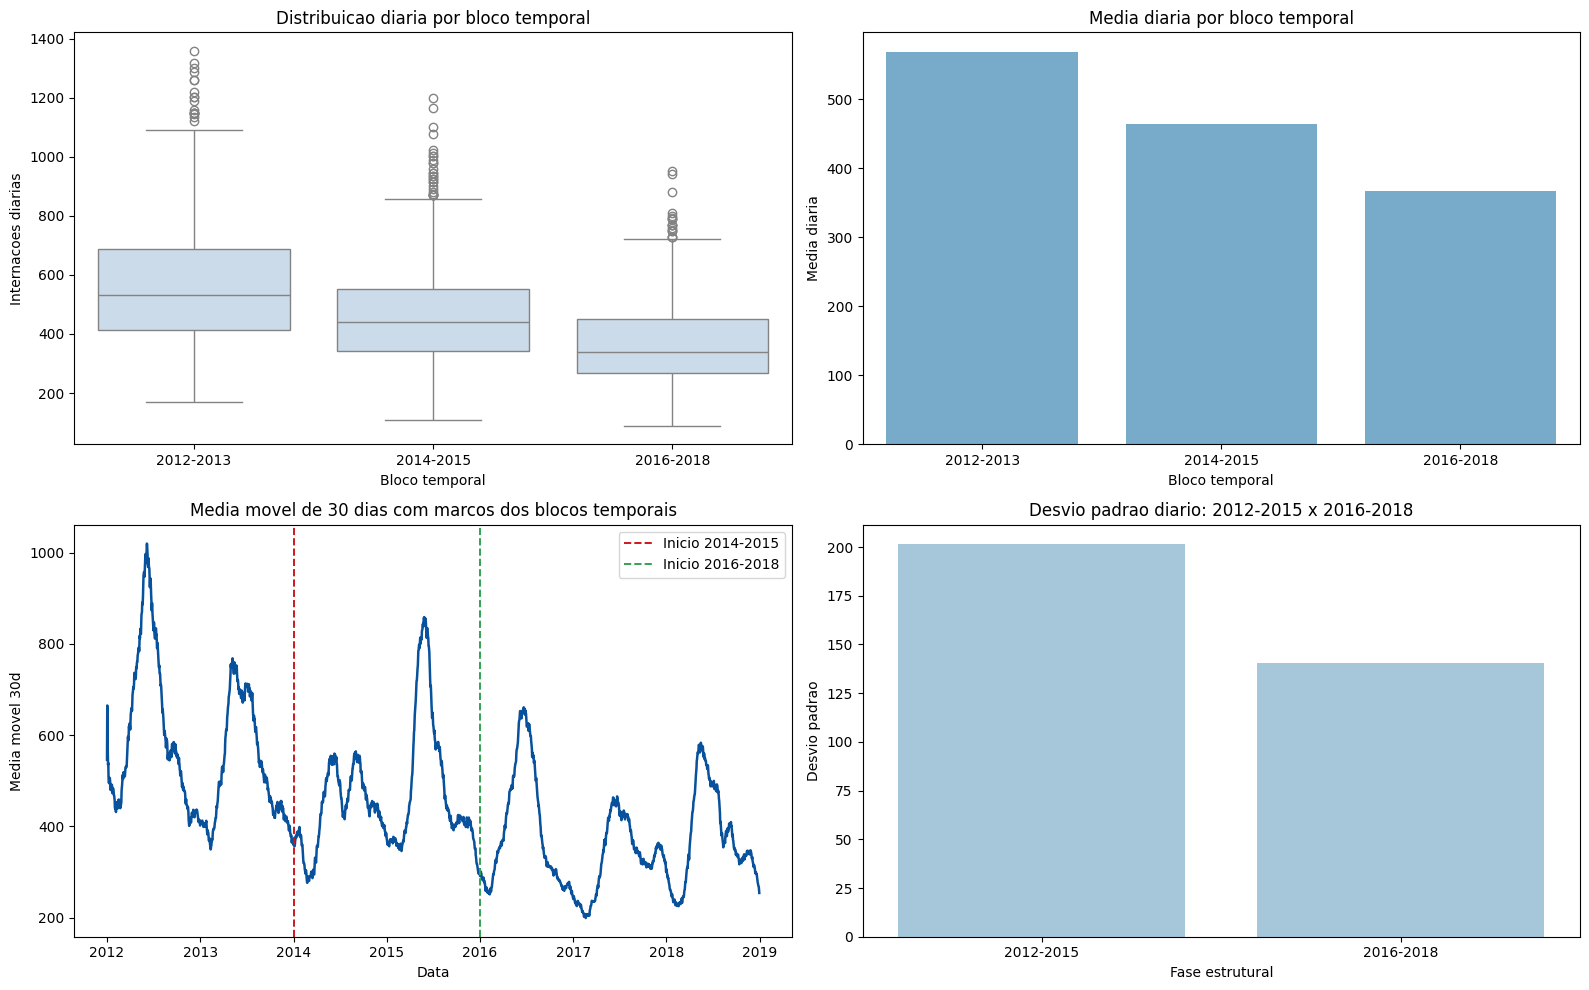

In [12]:
resumo_bloco_temporal = (
    df_eventos.groupby("bloco_temporal", observed=True)["num_internacoes"]
    .agg(
        n_dias="count",
        total="sum",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        p95=lambda s: s.quantile(0.95),
    )
    .reset_index()
)

resumo_fase_estrutura = (
    df_eventos.groupby("fase_estrutura", observed=True)["num_internacoes"]
    .agg(n_dias="count", media="mean", mediana="median", desvio_padrao="std", p95=lambda s: s.quantile(0.95))
    .reset_index()
)

display(resumo_bloco_temporal.round(2))
display(resumo_fase_estrutura.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=df_eventos.reset_index(), x="bloco_temporal", y="num_internacoes", color="#c6dbef", ax=axes[0, 0])
axes[0, 0].set_title("Distribuicao diaria por bloco temporal")
axes[0, 0].set_xlabel("Bloco temporal")
axes[0, 0].set_ylabel("Internacoes diarias")

sns.barplot(data=resumo_bloco_temporal, x="bloco_temporal", y="media", color="#6baed6", ax=axes[0, 1])
axes[0, 1].set_title("Media diaria por bloco temporal")
axes[0, 1].set_xlabel("Bloco temporal")
axes[0, 1].set_ylabel("Media diaria")

axes[1, 0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=1.8)
for data_ref, cor, rotulo in [
    (pd.Timestamp("2014-01-01"), "#cb181d", "Inicio 2014-2015"),
    (pd.Timestamp("2016-01-01"), "#31a354", "Inicio 2016-2018"),
]:
    axes[1, 0].axvline(data_ref, color=cor, linestyle="--", linewidth=1.4, label=rotulo)
axes[1, 0].set_title("Media movel de 30 dias com marcos dos blocos temporais")
axes[1, 0].set_xlabel("Data")
axes[1, 0].set_ylabel("Media movel 30d")
axes[1, 0].legend()

sns.barplot(data=resumo_fase_estrutura, x="fase_estrutura", y="desvio_padrao", color="#9ecae1", ax=axes[1, 1])
axes[1, 1].set_title("Desvio padrao diario: 2012-2015 x 2016-2018")
axes[1, 1].set_xlabel("Fase estrutural")
axes[1, 1].set_ylabel("Desvio padrao")

plt.tight_layout()
plt.show()

### Ondas epidemicas e mudancas abruptas de nivel/variancia

Para identificar ondas, usamos a media movel de 30 dias e procuramos picos suficientemente separados no tempo. Para detectar mudancas abruptas de nivel e de variabilidade, construimos escores baseados na diferenca entre as janelas atuais e as de 30 dias atras.

,data_pico,media_movel_30d,prominencia
1,2012-06-05,1019.67,588.00
5,2015-05-29,858.00,581.60
2,2013-05-07,768.30,418.60
0,2012-01-02,665.00,119.00
6,2016-06-21,660.97,409.67
8,2018-05-16,583.47,329.13
4,2014-09-02,564.47,218.33
3,2014-06-10,559.60,143.77
7,2017-06-22,465.90,240.57


,data,score,prominencia
4,2015-05-05,324.50,324.10
5,2015-07-11,246.10,245.73
2,2013-04-30,236.17,235.77
0,2012-06-05,235.67,227.20
1,2012-08-12,220.47,213.47
8,2018-04-30,215.73,215.60
7,2016-08-28,176.80,176.40
6,2016-06-07,169.90,168.50


,data,score,prominencia
9,2015-04-20,118.33,118.32
3,2013-04-15,95.58,95.44
1,2012-07-10,94.10,92.55
10,2015-07-12,83.36,83.35
4,2013-09-10,62.98,62.95
13,2016-04-25,56.85,56.56
11,2015-09-10,56.25,55.69
0,2012-03-27,55.10,47.62


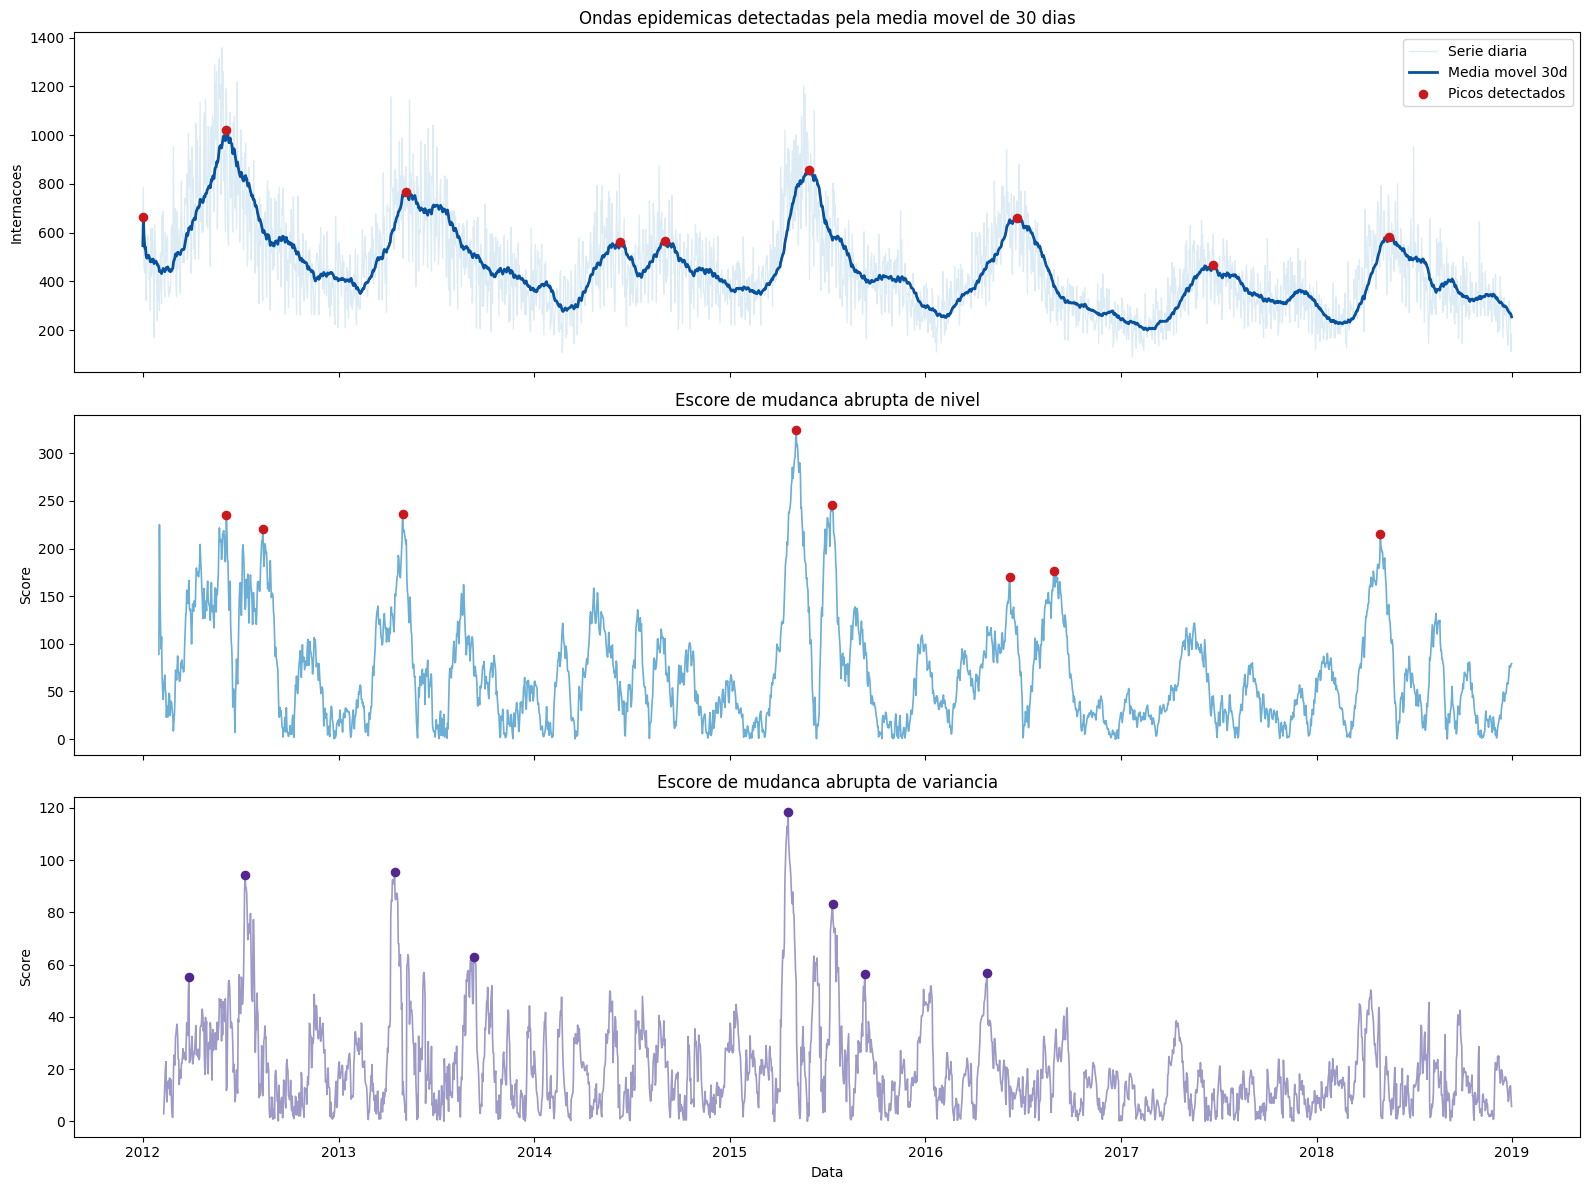

In [13]:
# Deteccao de ondas a partir da media movel de 30 dias.
serie_ondas = df_eventos["media_movel_30d"].dropna()
prominencia_ondas = max(float(serie_ondas.std() * 0.5), 5.0)
peaks_ondas, props_ondas = find_peaks(serie_ondas.to_numpy(), distance=45, prominence=prominencia_ondas)

ondas_detectadas = pd.DataFrame(
    {
        "data_pico": serie_ondas.index[peaks_ondas],
        "media_movel_30d": serie_ondas.iloc[peaks_ondas].to_numpy(),
        "prominencia": props_ondas.get("prominences", np.array([])),
    }
).sort_values("media_movel_30d", ascending=False)

# Escores diarios de mudanca de nivel e de variancia.
janela_mudanca = 30
df_eventos["score_mudanca_nivel"] = (df_eventos["media_movel_30d"] - df_eventos["media_movel_30d"].shift(janela_mudanca)).abs()
df_eventos["score_mudanca_variancia"] = (df_eventos["desvio_movel_30d"] - df_eventos["desvio_movel_30d"].shift(janela_mudanca)).abs()

candidatos_nivel = detectar_candidatos_por_score(df_eventos["score_mudanca_nivel"], distance=60, quantil_prom=0.92, top_n=8)
candidatos_variancia = detectar_candidatos_por_score(df_eventos["score_mudanca_variancia"], distance=60, quantil_prom=0.92, top_n=8)

display(ondas_detectadas.head(10).round(2))
display(candidatos_nivel.round(2))
display(candidatos_variancia.round(2))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df_eventos.index, df_eventos["num_internacoes"], color="#9ecae1", alpha=0.35, linewidth=0.9, label="Serie diaria")
axes[0].plot(df_eventos.index, df_eventos["media_movel_30d"], color="#08519c", linewidth=2, label="Media movel 30d")
axes[0].scatter(ondas_detectadas["data_pico"], ondas_detectadas["media_movel_30d"], color="#cb181d", s=35, zorder=3, label="Picos detectados")
axes[0].set_title("Ondas epidemicas detectadas pela media movel de 30 dias")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_eventos.index, df_eventos["score_mudanca_nivel"], color="#6baed6", linewidth=1.2)
axes[1].scatter(candidatos_nivel["data"], candidatos_nivel["score"], color="#cb181d", s=35, zorder=3)
axes[1].set_title("Escore de mudanca abrupta de nivel")
axes[1].set_ylabel("Score")

axes[2].plot(df_eventos.index, df_eventos["score_mudanca_variancia"], color="#9e9ac8", linewidth=1.2)
axes[2].scatter(candidatos_variancia["data"], candidatos_variancia["score"], color="#54278f", s=35, zorder=3)
axes[2].set_title("Escore de mudanca abrupta de variancia")
axes[2].set_xlabel("Data")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Changepoints em escala mensal

Para reduzir ruido diario e detectar melhor mudancas estruturais, agregamos a serie por mes. Depois aplicamos duas abordagens:
- **Pettitt**, para encontrar um ponto principal de ruptura;
- um **escore combinado** de mudanca de nivel e variabilidade mensal, para levantar varios changepoints candidatos.

,data_changepoint,estatistica_k,p_valor_aprox,n_observacoes
0,2015-08-01,1122.0,0.0,84


,data_changepoint,score,prominencia,media_mensal,desvio_mensal,score_changepoint
3,2015-04-01,7.908,7.445,727.100,158.706,7.908
0,2012-05-01,4.190,3.268,984.516,244.857,4.190
1,2013-04-01,3.267,2.789,755.300,130.418,3.267
2,2013-08-01,3.250,2.741,531.677,99.492,3.250
4,2018-04-01,3.046,2.737,543.467,97.753,3.046


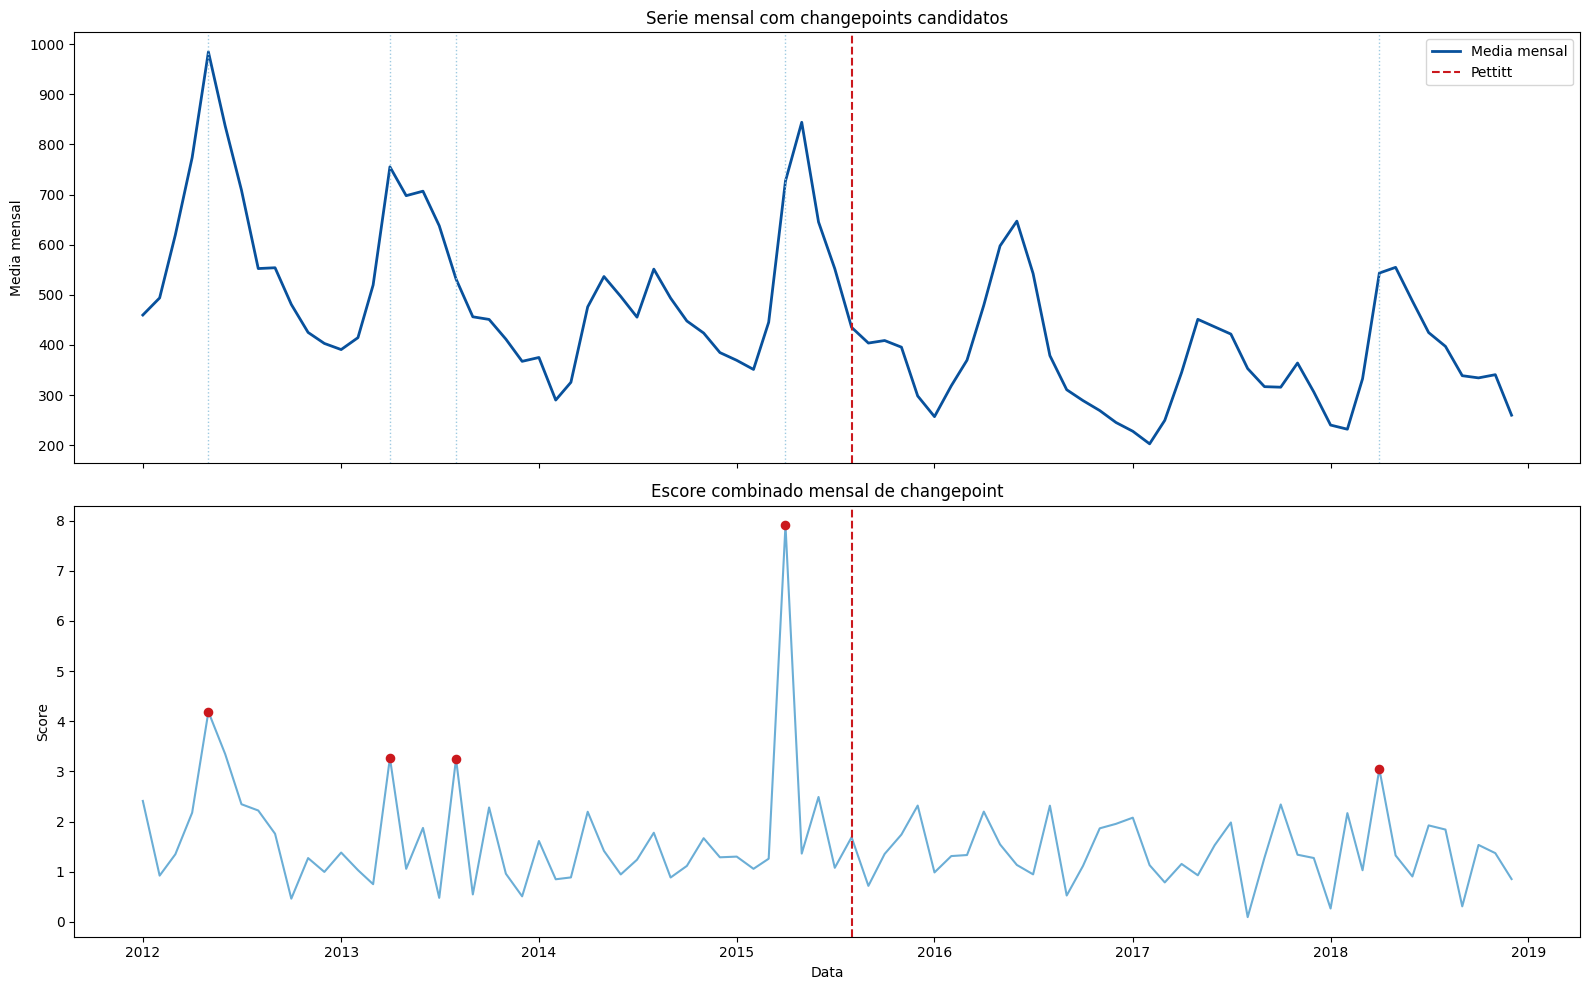

In [14]:
mensal_eventos = (
    df_eventos["num_internacoes"]
    .resample("MS")
    .agg(["mean", "median", "std", "sum"])
    .rename(columns={"mean": "media_mensal", "median": "mediana_mensal", "std": "desvio_mensal", "sum": "total_mensal"})
)

mensal_eventos["delta_media_abs"] = mensal_eventos["media_mensal"].diff().abs()
mensal_eventos["delta_desvio_abs"] = mensal_eventos["desvio_mensal"].diff().abs()
mensal_eventos["score_changepoint"] = normalizar_z(mensal_eventos["delta_media_abs"].fillna(0)).abs() + normalizar_z(mensal_eventos["delta_desvio_abs"].fillna(0)).abs()

resultado_pettitt = pettitt_test(mensal_eventos["media_mensal"])

candidatos_changepoint = detectar_candidatos_por_score(
    mensal_eventos["score_changepoint"],
    distance=2,
    quantil_prom=0.85,
    top_n=8,
).rename(columns={"data": "data_changepoint"})

candidatos_changepoint = candidatos_changepoint.merge(
    mensal_eventos[["media_mensal", "desvio_mensal", "score_changepoint"]],
    left_on="data_changepoint",
    right_index=True,
    how="left",
)

display(pd.DataFrame([resultado_pettitt]).round(4))
display(candidatos_changepoint.round(3))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(mensal_eventos.index, mensal_eventos["media_mensal"], color="#08519c", linewidth=2, label="Media mensal")
axes[0].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5, label="Pettitt")
for data_cp in candidatos_changepoint["data_changepoint"]:
    axes[0].axvline(data_cp, color="#9ecae1", linestyle=":", linewidth=1)
axes[0].set_title("Serie mensal com changepoints candidatos")
axes[0].set_ylabel("Media mensal")
axes[0].legend(loc="upper right")

axes[1].plot(mensal_eventos.index, mensal_eventos["score_changepoint"], color="#6baed6", linewidth=1.5)
axes[1].scatter(candidatos_changepoint["data_changepoint"], candidatos_changepoint["score"], color="#cb181d", s=35, zorder=3)
axes[1].axvline(resultado_pettitt["data_changepoint"], color="#cb181d", linestyle="--", linewidth=1.5)
axes[1].set_title("Escore combinado mensal de changepoint")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

Os resultados reforcam que a serie **nao e estacionaria ao longo de todo o periodo** e que ela passou por **mudancas de regime relevantes**. A comparacao entre os blocos temporais mostrou uma queda progressiva do nivel medio: a media diaria passou de **568,4** em **2012-2013** para **464,6** em **2014-2015** e **366,6** em **2016-2018**. Na comparacao binaria entre fases, a media caiu de **516,5** em **2012-2015** para **366,6 internacoes por dia** em **2016-2018**, uma reducao de cerca de **29,0%**. A dispersao tambem diminuiu bastante, com queda de aproximadamente **30,1%** no desvio padrao e de **29,7%** no percentil 95. Isso sugere que a parte final da serie opera em um patamar menor e menos volatil do que o observado na fase inicial.

A deteccao de ondas pela media movel de 30 dias mostrou picos muito expressivos em **2012-06-05 (1019,7)**, **2015-05-29 (858,0)** e **2013-05-07 (768,3)**, com novas ondas importantes em **2016-06-21 (661,0)** e **2018-05-16 (583,5)**. Isso mostra que os maiores surtos da serie ficaram concentrados sobretudo na metade inicial do historico, embora ainda existam episodios relevantes no trecho final. Em termos praticos, a dinamica da serie parece ser marcada por **ondas episodicas intensas** sobre uma tendencia geral de queda.

Os escores de mudanca abrupta de nivel apontaram datas muito concentradas em **2012-2015**, com destaque para **2015-05-05**, **2015-07-11**, **2013-04-30** e **2012-06-05**, alem de um sinal relevante em **2018-04-30**. Ja os escores de mudanca de variancia destacaram principalmente **2015-04-20**, **2013-04-15**, **2012-07-10**, **2015-07-12** e **2016-04-25**. Isso mostra que a serie nao mudou apenas de nivel: em momentos diferentes ela tambem mudou de estabilidade, com fases de maior e menor dispersao.

A analise mensal consolidou esse diagnostico. O teste de **Pettitt** identificou um changepoint principal em **2015-08-01**, com p-valor aproximado praticamente nulo, o que fornece evidencia forte de ruptura estrutural. Alem disso, os changepoints candidatos mais relevantes ficaram em meses como **2015-04**, **2012-05**, **2013-04**, **2013-08** e **2018-04**. Em conjunto, esses pontos sugerem que a serie passou por varios momentos de reorganizacao, e nao por uma unica mudanca isolada.

Outro aspecto importante e que os anos com grandes ondas tambem aparecem entre os mais instaveis, mas isso ocorre em fases diferentes do historico. O bloco de **2012-2015** concentra as ondas mais fortes e varias mudancas abruptas de nivel, enquanto **2016-2018** aparece em um patamar mais baixo, mas ainda com sinais de reorganizacao, especialmente em **2018**. Isso sugere que a serie mudou de forma multifacetada: primeiro com ondas muito intensas e depois com reorganizacao de nivel e volatilidade em um contexto de queda estrutural.

**Possiveis analises e consequencias**
- A modelagem nao deve assumir um unico regime temporal para toda a serie sem ao menos testar segmentacoes, dummies de ruptura ou avaliacao por janelas temporais.
- O ponto em torno de **2015-08** merece ser tratado explicitamente, porque ele aparece como a principal ruptura mensal da serie.
- Os anos **2012-2015** merecem investigacao mais detalhada, porque concentram as ondas mais fortes e varias transicoes abruptas de nivel.
- O fato de **2016-2018** ter nivel medio e dispersao menores sugere que modelos treinados em todo o historico podem superestimar essa fase mais recente se nao controlarem regime e tendencia.
- As ondas e changepoints detectados podem ser usados para guiar uma analise posterior com variaveis externas, como poluicao, clima, surtos e mudancas operacionais do sistema de saude.